In [1]:
import os
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import logging
import glob

# GLOBAL CONSTANTS
PATH_TO_FIGURES = "./fig/"
FIGSIZE = (9, 6)
LEGEND_FONTSIZE = 20
LABEL_FONTSIZE = 28
hatches = ['xx', '\\\\', '//', '--', '++', '||', 'o', 'O', '.', '*']
width = 0.35  # the width of the bars
line_width = 3.5
# colors = ['#7F449B', '#009D72', '#E5A023']
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
system = ["GAE", "vSoC", "Anbox", "Redroid", "MCon"]
font = {'family': 'Arial',
        'weight': 'normal',
        'size': LABEL_FONTSIZE}

# envsetup
plt.rc('font', **font)
plt.rcParams.update({'legend.handlelength': 1.3, 'legend.borderpad': 0.25,
                     "legend.labelspacing": 0.25, "legend.handletextpad": 0.5})
plt.rcParams['hatch.linewidth'] = line_width
pd.set_option("display.max_colwidth", 5000)
pd.set_option("display.max_columns", 10000)
pd.set_option("display.max_rows", 100)
os.makedirs(PATH_TO_FIGURES, exist_ok=True)
warnings.filterwarnings('ignore')

# refresh the fonts just installed
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

scale = [1, 2, 4, 8, 16, 32, 64]

In [2]:
# Hardcoded final plotting data (no file read, no post-processing)
scale = np.array([1, 2, 4, 8, 16, 32, 64])
mcon = np.array([53.30889713696077, 53.264037986252696, 49.42638708414176, 46.68647374980173, 40.08653554903333, 30.57663263148046, 24.46130610518437])
mcon1 = np.array([53.55303810504634, 53.29233922623623, 40.92049853247693, 27.823879722737477, 23.481154385450893, 5.689681685375981, 3.9827771797631866])
mcon2 = np.array([53.879502595850205, 52.92024051640286, 50.07738195333142, 42.10740147694955, 40.54298423797822, 29.96485540969927, 22.47364155727445])
mcon_std = np.array([2.585443943670588, 3.9926912476903227, 5.0975143620650885, 2.4760748159854287, 3.5268718570918396, 4.256337698283414, 5.618365761734107])
mcon1_std = np.array([2.7566721997296284, 2.2326190565981032, 3.952798204950118, 2.7536066922612705, 3.74286260814062, 1.8070271865094125, 1.8973785458348833])
mcon2_std = np.array([3.153613398804967, 3.7090857653022007, 3.6588712777525334, 3.5965292036723855, 7.292232111941654, 8.647993602492338, 9.512792962741573])
mcon_max = 32

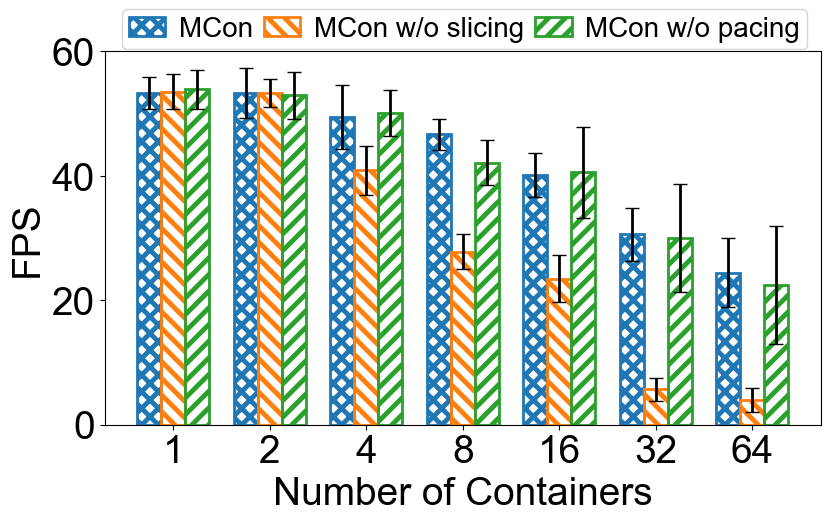

In [3]:
width = 0.25
x = np.arange(len(scale))

plt.figure(figsize=FIGSIZE)

# -------------------------
# 画三组柱子（颜色 + hatch + error bar）
# -------------------------
bars0 = plt.bar(
    x - width,
    mcon,
    width,
    yerr=mcon_std,
    label="MCon",
    color='none',
    hatch=hatches[0],
    capsize=5,
    edgecolor=colors[0],
    error_kw=dict(
        ecolor="black",   # 误差线颜色
        elinewidth=2,     # 误差线宽度
        # capsize=6,        # 小横帽长度
        # capthick=2        # 横帽线宽度
    ),
    linewidth=2
)

bars1 = plt.bar(
    x,
    mcon1,
    width,
    yerr=mcon1_std,
    label="MCon w/o slicing",
    color='none',
    hatch=hatches[1],
    capsize=5,
    edgecolor=colors[1],
    error_kw=dict(
        ecolor="black",   # 误差线颜色
        elinewidth=2,     # 误差线宽度
        # capsize=6,        # 小横帽长度
        # capthick=2        # 横帽线宽度
    ),
    linewidth=2
)

bars2 = plt.bar(
    x + width,
    mcon2,
    width,
    yerr=mcon2_std,
    label="MCon w/o pacing",
    color='none',
    hatch=hatches[2],
    capsize=5,
    edgecolor=colors[2],
    error_kw=dict(
        ecolor="black",   # 误差线颜色
        elinewidth=2,     # 误差线宽度
        # capsize=6,        # 小横帽长度
        # capthick=2        # 横帽线宽度
    ),
    linewidth=2
)

# -------------------------
# 坐标轴
# -------------------------
plt.xticks(x, scale, fontsize=LABEL_FONTSIZE)
plt.xlabel("Number of Containers", fontsize=LABEL_FONTSIZE)
plt.ylabel("FPS", fontsize=LABEL_FONTSIZE)
plt.ylim(0, 60)


# plt.legend(ncol=3, loc="upper left")
plt.legend(
    loc="upper left",          # 左上角对齐锚点
    ncol=3,                    # ✅ 两列排放
    # frameon=True,             # 显示边框
    bbox_to_anchor=(0.005, 1.15),  # ✅ 控制与图边框的距离（x, y）
    fontsize=20,
    # borderpad=0.6,            # 图例内容与边框的内边距
    # labelspacing=0.2,         # 每一项之间的竖直间距
    columnspacing=0.4,        # 两列之间的水平间距
    # handletextpad=0.6         # marker 与文字之间的间距
)
plt.tight_layout()

plt.savefig(PATH_TO_FIGURES + "fps_break_down.pdf", format="pdf", bbox_inches="tight", pad_inches=0)
plt.show()